In [40]:
pip install matplotlib pandas


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [48]:
RUN_SETS = {
    "e50": {
        "train": [
            ("logs/epochs/e50/train_run01.txt", "Run 01"),
            ("logs/epochs/e50/train_run02.txt", "Run 02"),
            ("logs/epochs/e50/train_run03.txt", "Run 03"),
        ],
        "eval": [
            ("logs/epochs/e50/eval_run01.txt", "Run 01"),
            ("logs/epochs/e50/eval_run02.txt", "Run 02"),
            ("logs/epochs/e50/eval_run03.txt", "Run 03"),
        ],
    },
    "e75": {
        "train": [
            ("logs/epochs/e75/train_run01.txt", "Run 01"),
            ("logs/epochs/e75/train_run02.txt", "Run 02"),
            ("logs/epochs/e75/train_run03.txt", "Run 03"),
        ],
        "eval": [
            ("logs/epochs/e75/eval_run01.txt", "Run 01"),
            ("logs/epochs/e75/eval_run02.txt", "Run 02"),
            ("logs/epochs/e75/eval_run03.txt", "Run 03"),
        ],
    },
    "lr2e5": {
        "train": [
            ("logs/lr/lr2e-5/train_run01.txt", "Run 01"),
            ("logs/lr/lr2e-5/train_run02.txt", "Run 02"),
            ("logs/lr/lr2e-5/train_run03.txt", "Run 03"),
        ],
        "eval": [
            ("logs/lr/lr2e-5/eval_run01.txt", "Run 01"),
            ("logs/lr/lr2e-5/eval_run02.txt", "Run 02"),
            ("logs/lr/lr2e-5/eval_run03.txt", "Run 03"),
        ],
    },
    "lr5e6": {
        "train": [
            ("logs/lr/lr5e-6/train_run01.txt", "Run 01"),
            ("logs/lr/lr5e-6/train_run02.txt", "Run 02"),
            ("logs/lr/lr5e-6/train_run03.txt", "Run 03"),
        ],
        "eval": [
            ("logs/lr/lr5e-6/eval_run01.txt", "Run 01"),
            ("logs/lr/lr5e-6/eval_run02.txt", "Run 02"),
            ("logs/lr/lr5e-6/eval_run03.txt", "Run 03"),
        ],
    },
    "t05": {
        "train": [
            ("logs/temp/t05/train_run01.txt", "Run 01"),
            ("logs/temp/t05/train_run02.txt", "Run 02"),
            ("logs/temp/t05/train_run03.txt", "Run 03"),
        ],
        "eval": [
            ("logs/temp/t05/eval_run01.txt", "Run 01"),
            ("logs/temp/t05/eval_run02.txt", "Run 02"),
            ("logs/temp/t05/eval_run03.txt", "Run 03"),
        ],
    },
    "t1": {
        "train": [
            ("logs/temp/t1/train_run01.txt", "Run 01"),
            ("logs/temp/t1/train_run02.txt", "Run 02"),
            ("logs/temp/t1/train_run03.txt", "Run 03"),
        ],
        "eval": [
            ("logs/temp/t1/eval_run01.txt", "Run 01"),
            ("logs/temp/t1/eval_run02.txt", "Run 02"),
            ("logs/temp/t1/eval_run03.txt", "Run 03"),
        ],
    },
}

train_colors = ["#c25326", "#294069", "#f1b756"]
train_offsets = [(8, 8), (8, -28), (-70, 8)]
eval_set_colors = {
    "e50": "#c25326",
    "lr2e5": "#294069",
    "lr5e6": "#2d7f5e",
    "e75": "#9b59b6",
}


In [42]:
import re
import matplotlib.pyplot as plt
import pandas as pd

TRAIN_EPOCH_RE = re.compile(
    r"Epoch\s+(\d+)/(\d+)\s+\|\s+loss=([0-9.]+)(?:\s+\|\s+silhouette=([0-9.]+))?"
)
EVAL_SECTION_RE = re.compile(r"===\s+(FROZEN_BASELINE|FINE_TUNED)\s+===")
EVAL_RANK_RE = re.compile(r"Rank-\s*(\d+) accuracy:\s*([0-9.]+)%")
EVAL_SIL_RE = re.compile(r"Silhouette score:\s*([-0-9.]+)")
CMC_RANKS = [1, 5, 10]


def parse_train_log(path):
    rows = []
    with open(path, "r", encoding="utf-8") as f:
        for line in f:
            match = TRAIN_EPOCH_RE.search(line)
            if match:
                rows.append({
                    "epoch": int(match.group(1)),
                    "loss": float(match.group(3)),
                    "silhouette": float(match.group(4)) if match.group(4) else None,
                })
    return pd.DataFrame(rows)



def plot_training_runs(runs, colors=None, offsets=None, figsize=(14, 5)):
    colors = colors or ["#c25326", "#294069", "#f1b756"]
    offsets = offsets or [(8, 8), (8, -28), (-70, 8)]

    fig, axes = plt.subplots(1, 2, figsize=figsize)
    summary_rows = []

    for i, (path, title) in enumerate(runs):
        df = parse_train_log(path)
        if df.empty:
            print(f"No epoch data found in: {path}")
            continue

        xy_offset = offsets[i % len(offsets)]
        color = colors[i % len(colors)]

        axes[0].plot(df["epoch"], df["loss"], marker="o", markersize=4, label=title, color=color)

        best_loss_idx = df["loss"].idxmin()
        best_loss_epoch = df.loc[best_loss_idx, "epoch"]
        best_loss_value = df.loc[best_loss_idx, "loss"]

        axes[0].scatter(best_loss_epoch, best_loss_value, s=100, marker="*", zorder=5, color=color)
        axes[0].annotate(
            f"{title}\nbest: ep {best_loss_epoch}\n{best_loss_value:.4f}",
            (best_loss_epoch, best_loss_value),
            textcoords="offset points",
            xytext=xy_offset,
            fontsize=7,
            bbox=dict(boxstyle="round,pad=0.2", fc="#FFF7FB", ec=color, alpha=0.9),
            arrowprops=dict(arrowstyle="->", lw=0.8, alpha=0.6),
        )

        sil_df = df.dropna(subset=["silhouette"])
        best_sil_epoch = None
        best_sil_value = None

        if not sil_df.empty:
            axes[1].plot(sil_df["epoch"], sil_df["silhouette"], marker="o", markersize=4, label=title, color=color)
            best_sil_idx = sil_df["silhouette"].idxmax()
            best_sil_epoch = sil_df.loc[best_sil_idx, "epoch"]
            best_sil_value = sil_df.loc[best_sil_idx, "silhouette"]
            axes[1].scatter(best_sil_epoch, best_sil_value, s=100, marker="*", zorder=5, color=color)
            axes[1].annotate(
                f"{title}\nbest: ep {best_sil_epoch}\n{best_sil_value:.4f}",
                (best_sil_epoch, best_sil_value),
                textcoords="offset points",
                xytext=xy_offset,
                fontsize=7,
                bbox=dict(boxstyle="round,pad=0.2", fc="#FFF7FB", ec=color, alpha=0.9),
                arrowprops=dict(arrowstyle="->", lw=0.8, alpha=0.6),
            )

        summary_rows.append({
            "Run": title,
            "Best Loss Epoch": best_loss_epoch,
            "Best Loss": best_loss_value,
            "Best Silhouette Epoch": best_sil_epoch,
            "Best Silhouette": best_sil_value,
        })

    axes[0].set_title("Loss", fontsize=11)
    axes[0].set_xlabel("Epoch", fontsize=9)
    axes[0].set_ylabel("Loss", fontsize=9)
    axes[0].tick_params(axis="both", labelsize=8)
    axes[0].grid(True, alpha=0.3)
    axes[0].legend(fontsize=8)

    axes[1].set_title("Silhouette Score", fontsize=11)
    axes[1].set_xlabel("Epoch", fontsize=9)
    axes[1].set_ylabel("Silhouette", fontsize=9)
    axes[1].tick_params(axis="both", labelsize=8)
    axes[1].grid(True, alpha=0.3)
    axes[1].legend(fontsize=8)

    plt.tight_layout()
    plt.show()

    return pd.DataFrame(summary_rows)



def print_train_summary(summary_df):
    print("\nBest values by run:")
    for _, row in summary_df.iterrows():
        print(
            f"{row['Run']}: best loss = {row['Best Loss']:.4f} at epoch {int(row['Best Loss Epoch'])}; "
            + (
                f"best silhouette = {row['Best Silhouette']:.4f} at epoch {int(row['Best Silhouette Epoch'])}"
                if pd.notna(row["Best Silhouette"])
                else "best silhouette = N/A"
            )
        )

    print("\nSummary table:")
    print(summary_df.to_string(index=False))

    loss_mean = summary_df["Best Loss"].mean()
    loss_std = summary_df["Best Loss"].std()
    sil_mean = summary_df["Best Silhouette"].mean()
    sil_std = summary_df["Best Silhouette"].std()
    loss_epoch_mean = summary_df["Best Loss Epoch"].mean()
    loss_epoch_std = summary_df["Best Loss Epoch"].std()
    sil_epoch_mean = summary_df["Best Silhouette Epoch"].mean()
    sil_epoch_std = summary_df["Best Silhouette Epoch"].std()

    print("\nMean ± standard deviation across runs:")
    print(f"Best Loss: {loss_mean:.4f} ± {loss_std:.4f}")
    print(f"Best Silhouette: {sil_mean:.4f} ± {sil_std:.4f}")
    print(f"Best Loss Epoch: {loss_epoch_mean:.2f} ± {loss_epoch_std:.2f}")
    print(f"Best Silhouette Epoch: {sil_epoch_mean:.2f} ± {sil_epoch_std:.2f}")



def analyze_training_runs(runs, colors=None, offsets=None, figsize=(14, 5)):
    summary_df = plot_training_runs(runs, colors=colors, offsets=offsets, figsize=figsize)
    print_train_summary(summary_df)
    return summary_df



def analyze_selected_train_runs(selected_run_sets, colors=None, offsets=None, figsize=(14, 5)):
    results = {}
    for run_set_name in selected_run_sets:
        print(f"\n{'=' * 20} {run_set_name} | Train {'=' * 20}")
        results[run_set_name] = analyze_training_runs(
            RUN_SETS[run_set_name]["train"],
            colors=colors,
            offsets=offsets,
            figsize=figsize,
        )
    return results



def parse_eval_log(path):
    sections = {
        "Frozen": {"Rank-1": None, "Rank-5": None, "Rank-10": None, "Silhouette": None},
        "Fine-tuned": {"Rank-1": None, "Rank-5": None, "Rank-10": None, "Silhouette": None},
    }
    current = None

    with open(path, "r", encoding="utf-8") as f:
        for line in f:
            section_match = EVAL_SECTION_RE.search(line)
            if section_match:
                current = "Frozen" if section_match.group(1) == "FROZEN_BASELINE" else "Fine-tuned"
                continue

            if current is None:
                continue

            rank_match = EVAL_RANK_RE.search(line)
            if rank_match:
                rank = int(rank_match.group(1))
                if rank in CMC_RANKS:
                    sections[current][f"Rank-{rank}"] = float(rank_match.group(2))
                continue

            sil_match = EVAL_SIL_RE.search(line)
            if sil_match:
                sections[current]["Silhouette"] = float(sil_match.group(1))

    return sections



def build_eval_summary(eval_runs):
    rows = []
    for path, title in eval_runs:
        metrics = parse_eval_log(path)
        rows.append({
            "Run": title,
            "Frozen Rank-1": metrics["Frozen"]["Rank-1"],
            "Frozen Rank-5": metrics["Frozen"]["Rank-5"],
            "Frozen Rank-10": metrics["Frozen"]["Rank-10"],
            "Frozen Silhouette": metrics["Frozen"]["Silhouette"],
            "Fine-tuned Rank-1": metrics["Fine-tuned"]["Rank-1"],
            "Fine-tuned Rank-5": metrics["Fine-tuned"]["Rank-5"],
            "Fine-tuned Rank-10": metrics["Fine-tuned"]["Rank-10"],
            "Fine-tuned Silhouette": metrics["Fine-tuned"]["Silhouette"],
        })
    return pd.DataFrame(rows)



def build_eval_aggregate(eval_summary_df):
    rows = []
    for condition in ["Frozen", "Fine-tuned"]:
        row = {"Condition": condition}
        for rank in CMC_RANKS:
            series = eval_summary_df[f"{condition} Rank-{rank}"]
            row[f"Rank-{rank} Mean"] = series.mean()
            row[f"Rank-{rank} Std"] = series.std()
        row["Silhouette Mean"] = eval_summary_df[f"{condition} Silhouette"].mean()
        row["Silhouette Std"] = eval_summary_df[f"{condition} Silhouette"].std()
        rows.append(row)
    return pd.DataFrame(rows)



def build_eval_comparison(selected_run_sets):
    rows = []
    aggregate_by_set = {}

    for run_set_name in selected_run_sets:
        eval_summary_df = build_eval_summary(RUN_SETS[run_set_name]["eval"])
        eval_aggregate_df = build_eval_aggregate(eval_summary_df)
        aggregate_by_set[run_set_name] = eval_aggregate_df

        for _, row in eval_aggregate_df.iterrows():
            rows.append({
                "Run Set": run_set_name,
                "Condition": row["Condition"],
                "Rank-1 Mean": row["Rank-1 Mean"],
                "Rank-1 Std": row["Rank-1 Std"],
                "Rank-5 Mean": row["Rank-5 Mean"],
                "Rank-5 Std": row["Rank-5 Std"],
                "Rank-10 Mean": row["Rank-10 Mean"],
                "Rank-10 Std": row["Rank-10 Std"],
                "Silhouette Mean": row["Silhouette Mean"],
                "Silhouette Std": row["Silhouette Std"],
            })

    return pd.DataFrame(rows), aggregate_by_set



def plot_eval_comparison(eval_comparison_df, set_colors=None):
    set_colors = set_colors or {}
    plt.figure(figsize=(8, 5))

    for run_set_name in eval_comparison_df["Run Set"].unique():
        subset = eval_comparison_df[eval_comparison_df["Run Set"] == run_set_name]
        color = set_colors.get(run_set_name, None)

        for condition, linestyle in [("Frozen", "--"), ("Fine-tuned", "-")]:
            row = subset[subset["Condition"] == condition].iloc[0]
            means = [row[f"Rank-{rank} Mean"] for rank in CMC_RANKS]
            stds = [row[f"Rank-{rank} Std"] for rank in CMC_RANKS]
            plt.plot(
                CMC_RANKS,
                means,
                marker="o",
                linewidth=2,
                linestyle=linestyle,
                color=color,
                label=f"{run_set_name} | {condition}",
            )
            plt.fill_between(
                CMC_RANKS,
                [m - s for m, s in zip(means, stds)],
                [m + s for m, s in zip(means, stds)],
                color=color,
                alpha=0.10,
            )

    plt.xticks(CMC_RANKS)
    plt.ylim(0, 100)
    plt.xlabel("CMC Rank")
    plt.ylabel("Accuracy (%)")
    plt.title("Eval Comparison Across Run Sets")
    plt.grid(True, alpha=0.3)
    plt.legend(fontsize=8)
    plt.tight_layout()
    plt.show()



def print_eval_comparison(eval_comparison_df):
    print("\nEval comparison table (mean ± std across runs in each set):")
    print(eval_comparison_df.to_string(index=False))

    for run_set_name in eval_comparison_df["Run Set"].unique():
        print(f"\n{run_set_name}:")
        subset = eval_comparison_df[eval_comparison_df["Run Set"] == run_set_name]
        for _, row in subset.iterrows():
            print(
                f"{row['Condition']}: "
                f"Rank-1 = {row['Rank-1 Mean']:.2f} ± {row['Rank-1 Std']:.2f}, "
                f"Rank-5 = {row['Rank-5 Mean']:.2f} ± {row['Rank-5 Std']:.2f}, "
                f"Rank-10 = {row['Rank-10 Mean']:.2f} ± {row['Rank-10 Std']:.2f}, "
                f"Silhouette = {row['Silhouette Mean']:.4f} ± {row['Silhouette Std']:.4f}"
            )



def analyze_eval_run_sets(selected_run_sets, set_colors=None):
    eval_comparison_df, aggregate_by_set = build_eval_comparison(selected_run_sets)
    plot_eval_comparison(eval_comparison_df, set_colors=set_colors)
    print_eval_comparison(eval_comparison_df)
    return eval_comparison_df, aggregate_by_set



def main(selected_run_sets=None, train_figsize=(14, 5)):
    if selected_run_sets is None:
        selected_run_sets = SELECTED_RUN_SETS

    train_results = analyze_selected_train_runs(
        selected_run_sets,
        colors=train_colors,
        offsets=train_offsets,
        figsize=train_figsize,
    )

    print(f"\n{'=' * 20} Eval Comparison {'=' * 20}")
    eval_comparison_df, eval_aggregate_by_set = analyze_eval_run_sets(
        selected_run_sets,
        set_colors=eval_set_colors,
    )

    return {
        "train_results": train_results,
        "eval_comparison_df": eval_comparison_df,
        "eval_aggregate_by_set": eval_aggregate_by_set,
    }



## Training Length


==================== e50 | Train ====================


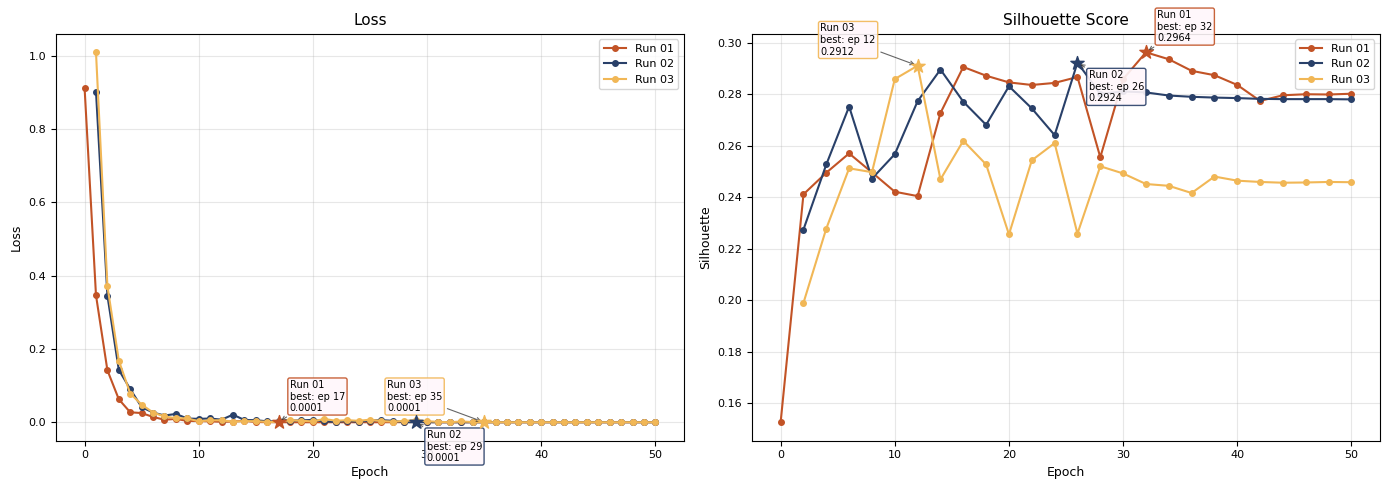


Best values by run:
Run 01: best loss = 0.0001 at epoch 17; best silhouette = 0.2964 at epoch 32
Run 02: best loss = 0.0001 at epoch 29; best silhouette = 0.2924 at epoch 26
Run 03: best loss = 0.0001 at epoch 35; best silhouette = 0.2912 at epoch 12

Summary table:
   Run  Best Loss Epoch  Best Loss  Best Silhouette Epoch  Best Silhouette
Run 01               17     0.0001                     32           0.2964
Run 02               29     0.0001                     26           0.2924
Run 03               35     0.0001                     12           0.2912

Mean ± standard deviation across runs:
Best Loss: 0.0001 ± 0.0000
Best Silhouette: 0.2933 ± 0.0027
Best Loss Epoch: 27.00 ± 9.17
Best Silhouette Epoch: 23.33 ± 10.26

==================== e75 | Train ====================


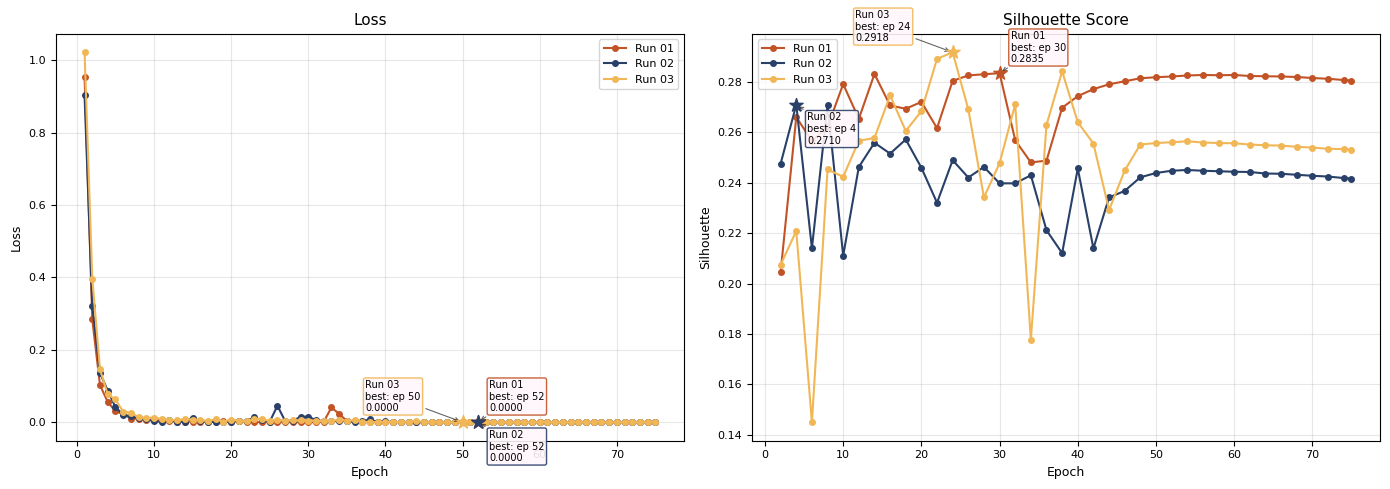


Best values by run:
Run 01: best loss = 0.0000 at epoch 52; best silhouette = 0.2835 at epoch 30
Run 02: best loss = 0.0000 at epoch 52; best silhouette = 0.2710 at epoch 4
Run 03: best loss = 0.0000 at epoch 50; best silhouette = 0.2918 at epoch 24

Summary table:
   Run  Best Loss Epoch  Best Loss  Best Silhouette Epoch  Best Silhouette
Run 01               52        0.0                     30           0.2835
Run 02               52        0.0                      4           0.2710
Run 03               50        0.0                     24           0.2918

Mean ± standard deviation across runs:
Best Loss: 0.0000 ± 0.0000
Best Silhouette: 0.2821 ± 0.0105
Best Loss Epoch: 51.33 ± 1.15
Best Silhouette Epoch: 19.33 ± 13.61

==================== Eval Comparison ====================


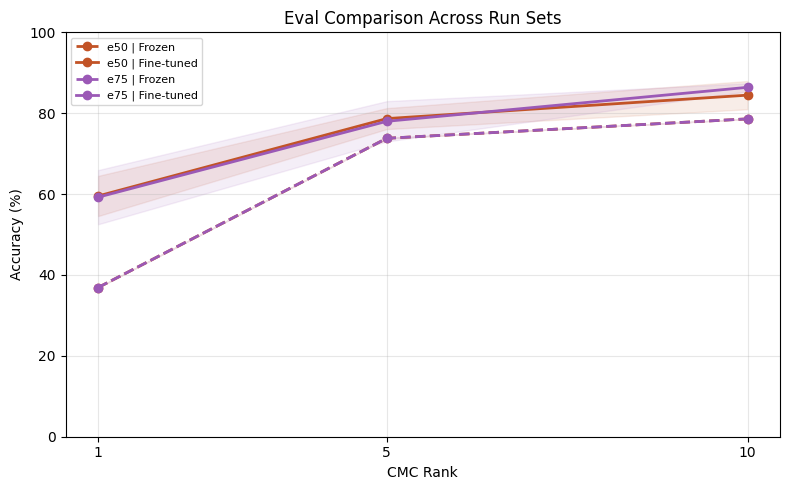


Eval comparison table (mean ± std across runs in each set):
Run Set  Condition  Rank-1 Mean  Rank-1 Std  Rank-5 Mean  Rank-5 Std  Rank-10 Mean  Rank-10 Std  Silhouette Mean  Silhouette Std
    e50     Frozen    36.900000    0.000000    73.800000    0.000000     78.600000     0.000000        -0.002500        0.000000
    e50 Fine-tuned    59.533333    4.966219    78.666667    2.589080     84.466667     3.494758         0.188567        0.015955
    e75     Frozen    36.900000    0.000000    73.800000    0.000000     78.600000     0.000000        -0.002500        0.000000
    e75 Fine-tuned    59.233333    6.697263    78.000000    4.978956     86.400000     1.000000         0.176467        0.033349

e50:
Frozen: Rank-1 = 36.90 ± 0.00, Rank-5 = 73.80 ± 0.00, Rank-10 = 78.60 ± 0.00, Silhouette = -0.0025 ± 0.0000
Fine-tuned: Rank-1 = 59.53 ± 4.97, Rank-5 = 78.67 ± 2.59, Rank-10 = 84.47 ± 3.49, Silhouette = 0.1886 ± 0.0160

e75:
Frozen: Rank-1 = 36.90 ± 0.00, Rank-5 = 73.80 ± 0.00, Rank-10 =

,Run Set,Condition,Rank-1 Mean,Rank-1 Std,Rank-5 Mean,Rank-5 Std,Rank-10 Mean,Rank-10 Std,Silhouette Mean,Silhouette Std
0,e50,Frozen,36.900000,0.000000,73.800000,0.000000,78.600000,0.000000,-0.002500,0.000000
1,e50,Fine-tuned,59.533333,4.966219,78.666667,2.589080,84.466667,3.494758,0.188567,0.015955
2,e75,Frozen,36.900000,0.000000,73.800000,0.000000,78.600000,0.000000,-0.002500,0.000000
3,e75,Fine-tuned,59.233333,6.697263,78.000000,4.978956,86.400000,1.000000,0.176467,0.033349


In [47]:
SELECTED_RUN_SETS = ["e50", "e75"] 
results = main(selected_run_sets=SELECTED_RUN_SETS)
results["eval_comparison_df"]

## Learning Rate


==================== e50 | Train ====================


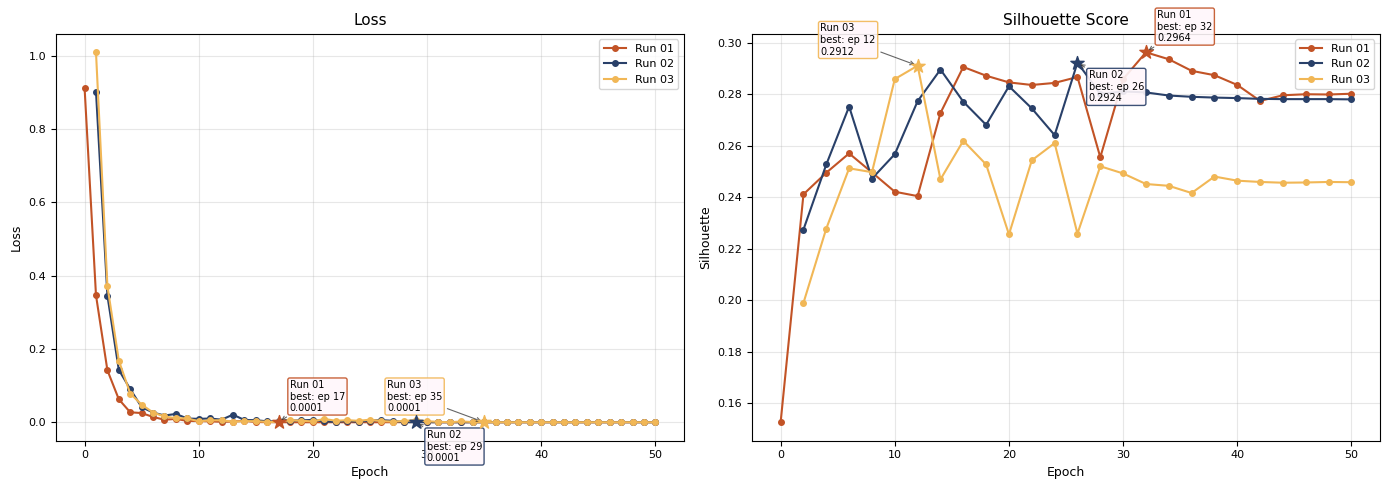


Best values by run:
Run 01: best loss = 0.0001 at epoch 17; best silhouette = 0.2964 at epoch 32
Run 02: best loss = 0.0001 at epoch 29; best silhouette = 0.2924 at epoch 26
Run 03: best loss = 0.0001 at epoch 35; best silhouette = 0.2912 at epoch 12

Summary table:
   Run  Best Loss Epoch  Best Loss  Best Silhouette Epoch  Best Silhouette
Run 01               17     0.0001                     32           0.2964
Run 02               29     0.0001                     26           0.2924
Run 03               35     0.0001                     12           0.2912

Mean ± standard deviation across runs:
Best Loss: 0.0001 ± 0.0000
Best Silhouette: 0.2933 ± 0.0027
Best Loss Epoch: 27.00 ± 9.17
Best Silhouette Epoch: 23.33 ± 10.26

==================== lr2e5 | Train ====================


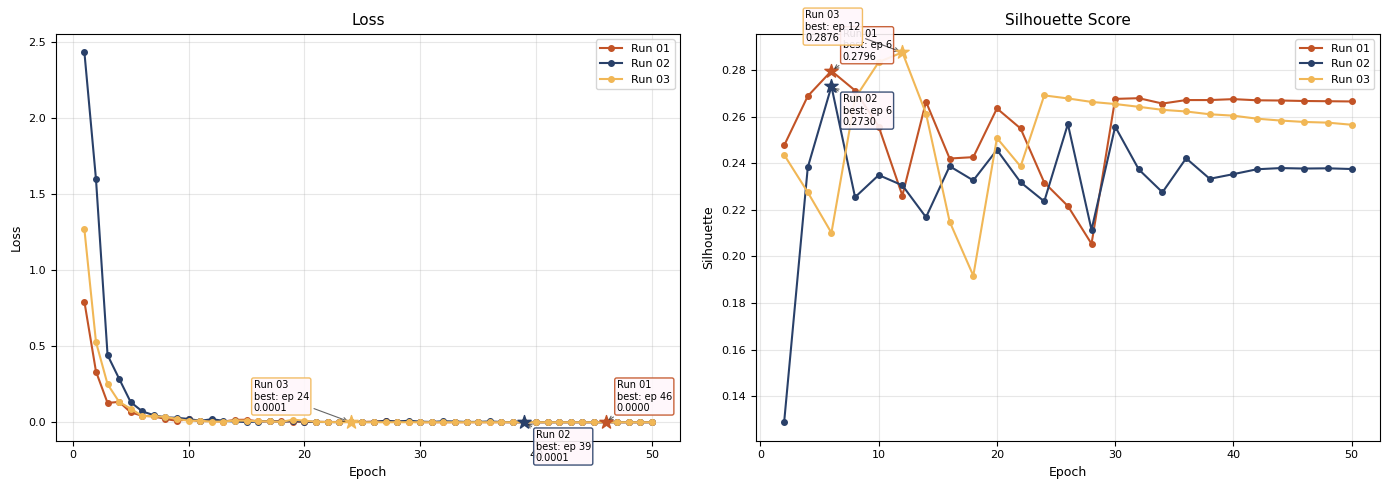


Best values by run:
Run 01: best loss = 0.0000 at epoch 46; best silhouette = 0.2796 at epoch 6
Run 02: best loss = 0.0001 at epoch 39; best silhouette = 0.2730 at epoch 6
Run 03: best loss = 0.0001 at epoch 24; best silhouette = 0.2876 at epoch 12

Summary table:
   Run  Best Loss Epoch  Best Loss  Best Silhouette Epoch  Best Silhouette
Run 01               46     0.0000                      6           0.2796
Run 02               39     0.0001                      6           0.2730
Run 03               24     0.0001                     12           0.2876

Mean ± standard deviation across runs:
Best Loss: 0.0001 ± 0.0001
Best Silhouette: 0.2801 ± 0.0073
Best Loss Epoch: 36.33 ± 11.24
Best Silhouette Epoch: 8.00 ± 3.46

==================== lr5e6 | Train ====================


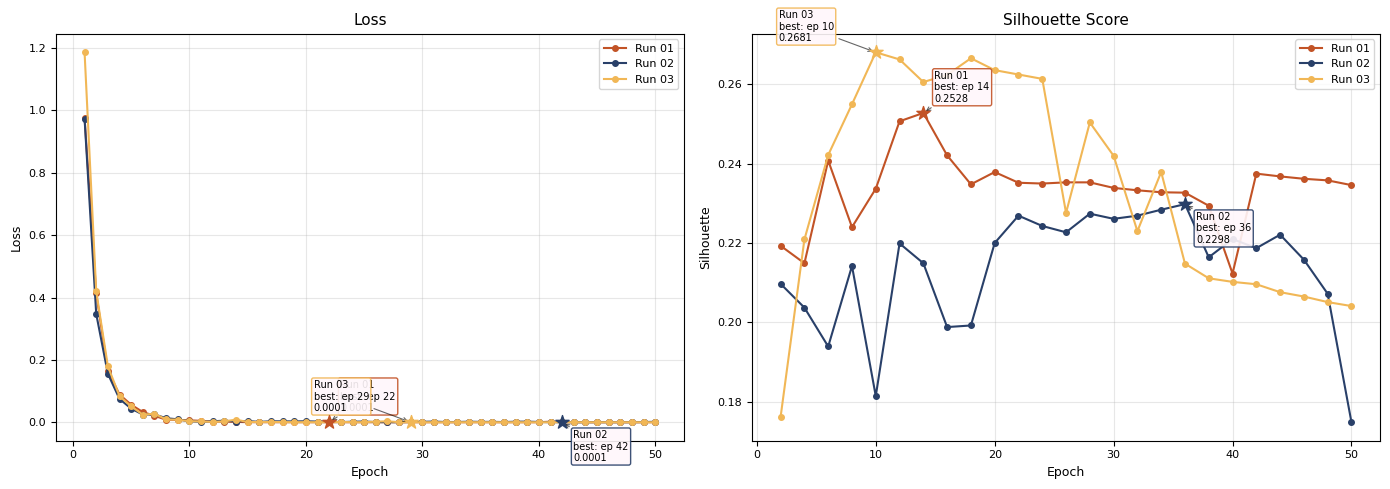


Best values by run:
Run 01: best loss = 0.0001 at epoch 22; best silhouette = 0.2528 at epoch 14
Run 02: best loss = 0.0001 at epoch 42; best silhouette = 0.2298 at epoch 36
Run 03: best loss = 0.0001 at epoch 29; best silhouette = 0.2681 at epoch 10

Summary table:
   Run  Best Loss Epoch  Best Loss  Best Silhouette Epoch  Best Silhouette
Run 01               22     0.0001                     14           0.2528
Run 02               42     0.0001                     36           0.2298
Run 03               29     0.0001                     10           0.2681

Mean ± standard deviation across runs:
Best Loss: 0.0001 ± 0.0000
Best Silhouette: 0.2502 ± 0.0193
Best Loss Epoch: 31.00 ± 10.15
Best Silhouette Epoch: 20.00 ± 14.00

==================== Eval Comparison ====================


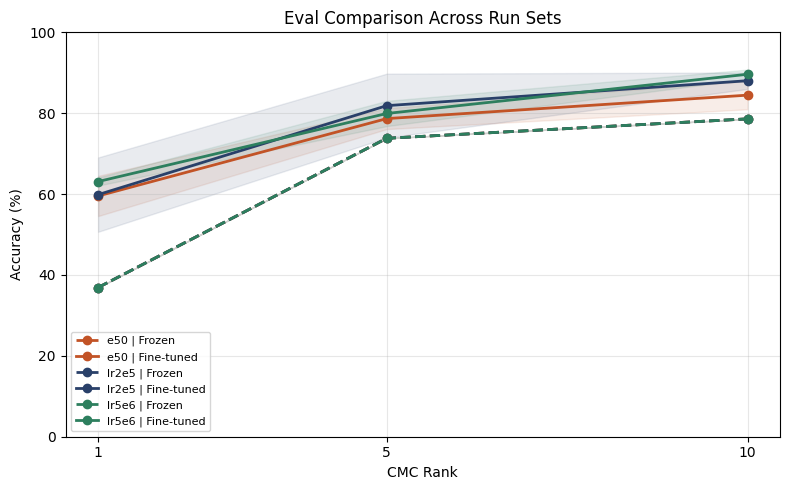


Eval comparison table (mean ± std across runs in each set):
Run Set  Condition  Rank-1 Mean  Rank-1 Std  Rank-5 Mean  Rank-5 Std  Rank-10 Mean  Rank-10 Std  Silhouette Mean  Silhouette Std
    e50     Frozen    36.900000    0.000000    73.800000    0.000000     78.600000     0.000000        -0.002500        0.000000
    e50 Fine-tuned    59.533333    4.966219    78.666667    2.589080     84.466667     3.494758         0.188567        0.015955
  lr2e5     Frozen    36.900000    0.000000    73.800000    0.000000     78.600000     0.000000        -0.002500        0.000000
  lr2e5 Fine-tuned    59.866667    9.187129    81.866667    7.915386     88.033333     2.025669         0.180933        0.047230
  lr5e6     Frozen    36.900000    0.000000    73.800000    0.000000     78.600000     0.000000        -0.002500        0.000000
  lr5e6 Fine-tuned    63.100000    1.000000    79.933333    3.121431     89.633333     1.154701         0.173667        0.022701

e50:
Frozen: Rank-1 = 36.90 ± 0.00,

,Run Set,Condition,Rank-1 Mean,Rank-1 Std,Rank-5 Mean,Rank-5 Std,Rank-10 Mean,Rank-10 Std,Silhouette Mean,Silhouette Std
0,e50,Frozen,36.900000,0.000000,73.800000,0.000000,78.600000,0.000000,-0.002500,0.000000
1,e50,Fine-tuned,59.533333,4.966219,78.666667,2.589080,84.466667,3.494758,0.188567,0.015955
2,lr2e5,Frozen,36.900000,0.000000,73.800000,0.000000,78.600000,0.000000,-0.002500,0.000000
3,lr2e5,Fine-tuned,59.866667,9.187129,81.866667,7.915386,88.033333,2.025669,0.180933,0.047230
4,lr5e6,Frozen,36.900000,0.000000,73.800000,0.000000,78.600000,0.000000,-0.002500,0.000000
5,lr5e6,Fine-tuned,63.100000,1.000000,79.933333,3.121431,89.633333,1.154701,0.173667,0.022701


In [45]:
SELECTED_RUN_SETS = ["e50", "lr2e5", "lr5e6"] 
results = main(selected_run_sets=SELECTED_RUN_SETS)
results["eval_comparison_df"]


## Temperature


==================== e50 | Train ====================


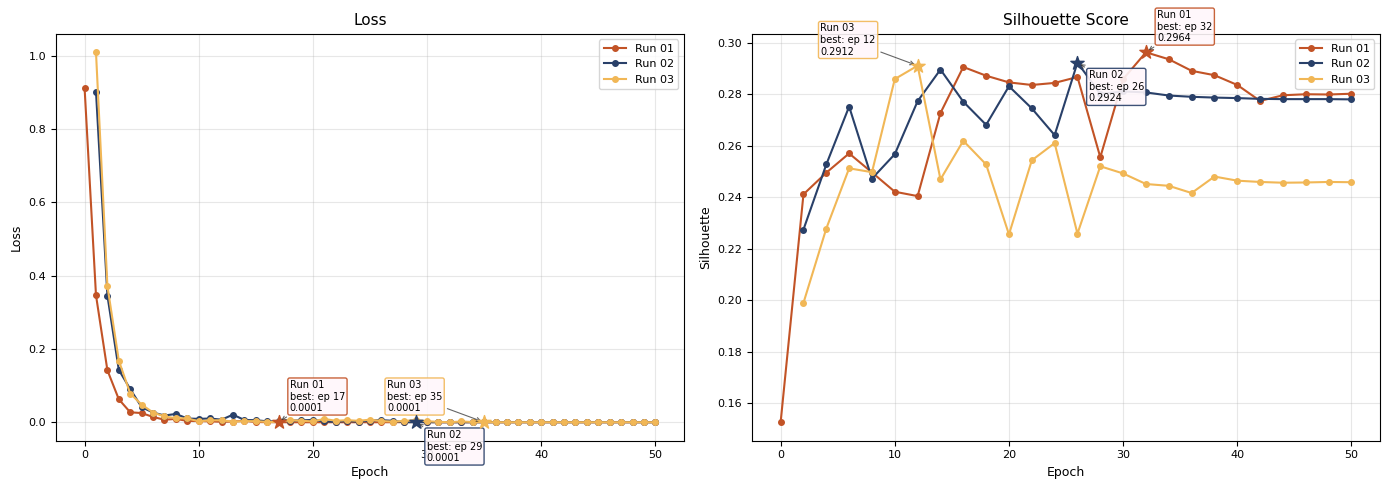


Best values by run:
Run 01: best loss = 0.0001 at epoch 17; best silhouette = 0.2964 at epoch 32
Run 02: best loss = 0.0001 at epoch 29; best silhouette = 0.2924 at epoch 26
Run 03: best loss = 0.0001 at epoch 35; best silhouette = 0.2912 at epoch 12

Summary table:
   Run  Best Loss Epoch  Best Loss  Best Silhouette Epoch  Best Silhouette
Run 01               17     0.0001                     32           0.2964
Run 02               29     0.0001                     26           0.2924
Run 03               35     0.0001                     12           0.2912

Mean ± standard deviation across runs:
Best Loss: 0.0001 ± 0.0000
Best Silhouette: 0.2933 ± 0.0027
Best Loss Epoch: 27.00 ± 9.17
Best Silhouette Epoch: 23.33 ± 10.26

==================== t05 | Train ====================


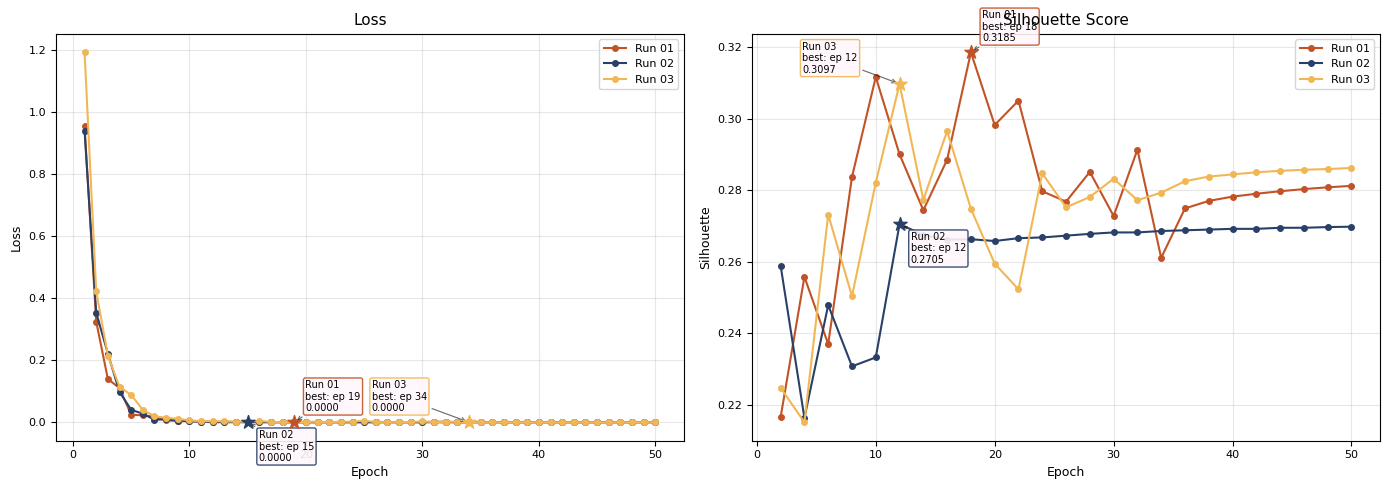


Best values by run:
Run 01: best loss = 0.0000 at epoch 19; best silhouette = 0.3185 at epoch 18
Run 02: best loss = 0.0000 at epoch 15; best silhouette = 0.2705 at epoch 12
Run 03: best loss = 0.0000 at epoch 34; best silhouette = 0.3097 at epoch 12

Summary table:
   Run  Best Loss Epoch  Best Loss  Best Silhouette Epoch  Best Silhouette
Run 01               19        0.0                     18           0.3185
Run 02               15        0.0                     12           0.2705
Run 03               34        0.0                     12           0.3097

Mean ± standard deviation across runs:
Best Loss: 0.0000 ± 0.0000
Best Silhouette: 0.2996 ± 0.0256
Best Loss Epoch: 22.67 ± 10.02
Best Silhouette Epoch: 14.00 ± 3.46

==================== t1 | Train ====================


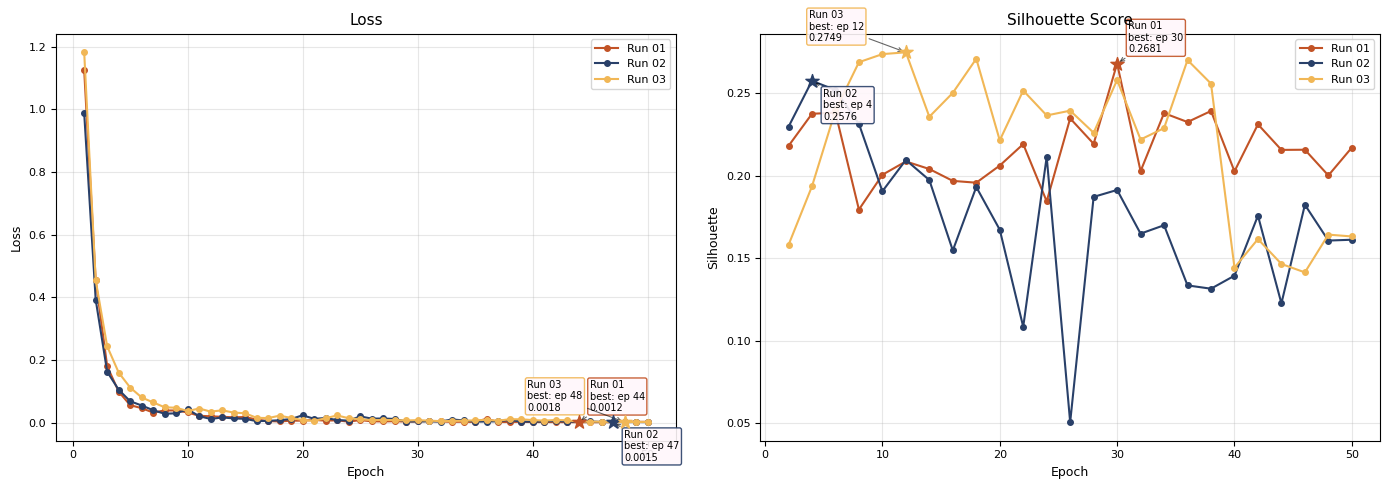


Best values by run:
Run 01: best loss = 0.0012 at epoch 44; best silhouette = 0.2681 at epoch 30
Run 02: best loss = 0.0015 at epoch 47; best silhouette = 0.2576 at epoch 4
Run 03: best loss = 0.0018 at epoch 48; best silhouette = 0.2749 at epoch 12

Summary table:
   Run  Best Loss Epoch  Best Loss  Best Silhouette Epoch  Best Silhouette
Run 01               44     0.0012                     30           0.2681
Run 02               47     0.0015                      4           0.2576
Run 03               48     0.0018                     12           0.2749

Mean ± standard deviation across runs:
Best Loss: 0.0015 ± 0.0003
Best Silhouette: 0.2669 ± 0.0087
Best Loss Epoch: 46.33 ± 2.08
Best Silhouette Epoch: 15.33 ± 13.32

==================== Eval Comparison ====================


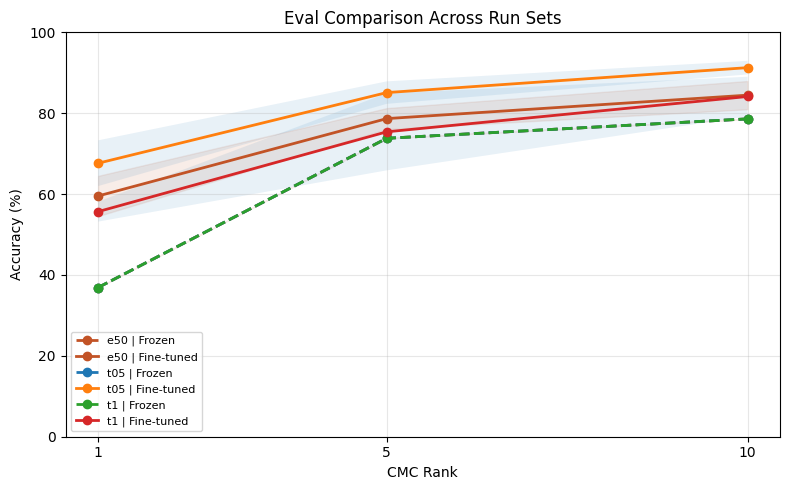


Eval comparison table (mean ± std across runs in each set):
Run Set  Condition  Rank-1 Mean  Rank-1 Std  Rank-5 Mean  Rank-5 Std  Rank-10 Mean  Rank-10 Std  Silhouette Mean  Silhouette Std
    e50     Frozen    36.900000    0.000000    73.800000    0.000000     78.600000     0.000000        -0.002500        0.000000
    e50 Fine-tuned    59.533333    4.966219    78.666667    2.589080     84.466667     3.494758         0.188567        0.015955
    t05     Frozen    36.900000    0.000000    73.800000    0.000000     78.600000     0.000000        -0.002500        0.000000
    t05 Fine-tuned    67.633333    5.651843    85.100000    2.771281     91.266667     1.674316         0.204367        0.018027
     t1     Frozen    36.900000    0.000000    73.800000    0.000000     78.600000     0.000000        -0.002500        0.000000
     t1 Fine-tuned    55.666667    2.470493    75.400000    9.526279     84.133333     4.880915         0.108767        0.062821

e50:
Frozen: Rank-1 = 36.90 ± 0.00,

,Run Set,Condition,Rank-1 Mean,Rank-1 Std,Rank-5 Mean,Rank-5 Std,Rank-10 Mean,Rank-10 Std,Silhouette Mean,Silhouette Std
0,e50,Frozen,36.900000,0.000000,73.800000,0.000000,78.600000,0.000000,-0.002500,0.000000
1,e50,Fine-tuned,59.533333,4.966219,78.666667,2.589080,84.466667,3.494758,0.188567,0.015955
2,t05,Frozen,36.900000,0.000000,73.800000,0.000000,78.600000,0.000000,-0.002500,0.000000
3,t05,Fine-tuned,67.633333,5.651843,85.100000,2.771281,91.266667,1.674316,0.204367,0.018027
4,t1,Frozen,36.900000,0.000000,73.800000,0.000000,78.600000,0.000000,-0.002500,0.000000
5,t1,Fine-tuned,55.666667,2.470493,75.400000,9.526279,84.133333,4.880915,0.108767,0.062821


In [49]:
SELECTED_RUN_SETS = ["e50", "t05", "t1"] 
results = main(selected_run_sets=SELECTED_RUN_SETS)
results["eval_comparison_df"]